# Proyecto Deep Learning - **SUDOKU**

### Importar librerías

In [1]:
# Matrices y arrays
import numpy as np

# Visualizaciones y procesamiento de imágenes
import matplotlib.pyplot as plt

# Manejo de rutas de archivos
from pathlib import Path

### Definir rutas

In [2]:
# Definir root
PROJECT_ROOT = Path("..")

OUTPUTS_DIR = PROJECT_ROOT / "notebooks" / "outputs"

SUDOKU_MATRIX_PATH = OUTPUTS_DIR / "sudoku_matrix_corrected.npy"
SUDOKU_SOLUTION_PATH = OUTPUTS_DIR / "sudoku_solution.npy"

print("Ruta matriz:", SUDOKU_MATRIX_PATH)
print("Existe matriz:", SUDOKU_MATRIX_PATH.exists())

Ruta matriz: ..\notebooks\outputs\sudoku_matrix_corrected.npy
Existe matriz: True


## 1. Cargar matriz ``9x9``

In [3]:
sudoku_matrix = np.load(SUDOKU_MATRIX_PATH)

print("Matriz inicial:")
print(sudoku_matrix)

print("\nForma:", sudoku_matrix.shape)

Matriz inicial:
[[0 2 0 0 0 5 1 0 0]
 [9 0 0 4 3 1 0 0 5]
 [5 3 0 0 0 8 0 7 6]
 [0 0 8 1 0 0 0 6 0]
 [2 1 0 0 0 0 0 5 3]
 [0 4 0 0 0 9 2 0 0]
 [4 9 0 5 0 0 0 8 7]
 [7 0 0 6 2 4 0 0 1]
 [0 0 6 9 0 0 0 4 0]]

Forma: (9, 9)


## 2. Validar matriz inicial

In [ ]:
# Función para validar el formato de la matriz inicial
# 0 = celda vacía
# 1-9 = números detectados/corregidos

def validate_sudoku_matrix(matrix):
    matrix = np.array(matrix)

    if matrix.shape != (9, 9):
        return False, "La matriz debe tener forma 9x9."

    if not np.all((matrix >= 0) & (matrix <= 9)):
        return False, "La matriz solo puede contener valores entre 0 y 9."

    return True, "Matriz válida."


is_valid, message = validate_sudoku_matrix(sudoku_matrix)

print(message)

Matriz válida.


## 3. Crear solver de Sudoku

### 3.1. Validar reglas del Sudoku inicial

In [ ]:
# Validar reglas del Sudoku inicial

def is_valid_group(values):
    values = [value for value in values if value != 0]  # Ignora los 0's (celda vacía)
    return len(values) == len(set(values)) # detectar repetidos

def validate_sudoku_rules(board):
    board = np.array(board)

    # Validar filas -  revisa si hay números repetidos
    for row in range(9):
        if not is_valid_group(board[row, :]):
            return False, f"Conflicto en la fila {row + 1}"

    # Validar columnas -  revisa si hay números repetidos
    for col in range(9):
        if not is_valid_group(board[:, col]):
            return False, f"Conflicto en la columna {col + 1}"

    # Validar bloques 3x3 -  revisa si hay números repetidos
    for block_row in range(0, 9, 3):
        for block_col in range(0, 9, 3):
            block = board[block_row:block_row+3, block_col:block_col+3].ravel()

            if not is_valid_group(block):
                return False, (
                    f"Conflicto en el bloque "
                    f"({block_row // 3 + 1}, {block_col // 3 + 1})"
                )

    return True, "La matriz cumple las reglas iniciales del Sudoku."


rules_valid, rules_message = validate_sudoku_rules(sudoku_matrix)

print(rules_message)

La matriz cumple las reglas iniciales del Sudoku.


## 4. Resolver Sudoku

In [ ]:
# Solver de Sudoku
def find_empty_cell(board):
    for row in range(9):
        for col in range(9):
            if board[row][col] == 0:
                return row, col
    return None


def is_valid_move(board, number, position):
    row, col = position

    # Revisar fila
    if number in board[row, :]:
        return False

    # Revisar columna
    if number in board[:, col]:
        return False

    # Revisar bloque 3x3
    block_row = (row // 3) * 3
    block_col = (col // 3) * 3

    block = board[block_row:block_row+3, block_col:block_col+3]

    if number in block:
        return False

    return True


def solve_sudoku(board):
    empty_cell = find_empty_cell(board)

    if empty_cell is None:
        return True

    row, col = empty_cell

    for number in range(1, 10):
        if is_valid_move(board, number, (row, col)):
            board[row][col] = number

            if solve_sudoku(board):
                return True

            board[row][col] = 0

    return False

In [ ]:
# Resolver Sudoku
sudoku_solution = sudoku_matrix.copy()

if not rules_valid:
    print("No se puede resolver porque la matriz inicial tiene conflictos.")
    print(rules_message)
else:
    solved = solve_sudoku(sudoku_solution)

    if solved:
        print("Sudoku resuelto:")
        print(sudoku_solution)
    else:
        print("No se encontró solución para este Sudoku.")

Sudoku resuelto:
[[8 2 4 7 6 5 1 3 9]
 [9 6 7 4 3 1 8 2 5]
 [5 3 1 2 9 8 4 7 6]
 [3 7 8 1 5 2 9 6 4]
 [2 1 9 8 4 6 7 5 3]
 [6 4 5 3 7 9 2 1 8]
 [4 9 2 5 1 3 6 8 7]
 [7 8 3 6 2 4 5 9 1]
 [1 5 6 9 8 7 3 4 2]]


## 5. Validar solución

In [8]:
# Función para validar la solución final
def validate_complete_solution(board):
    board = np.array(board)
    expected_values = set(range(1, 10))

    # Filas
    for row in range(9):
        if set(board[row, :]) != expected_values:
            return False, f"Error en fila {row + 1}"

    # Columnas
    for col in range(9):
        if set(board[:, col]) != expected_values:
            return False, f"Error en columna {col + 1}"

    # Bloques 3x3
    for block_row in range(0, 9, 3):
        for block_col in range(0, 9, 3):
            block = board[block_row:block_row+3, block_col:block_col+3].ravel()

            if set(block) != expected_values:
                return False, (
                    f"Error en bloque "
                    f"({block_row // 3 + 1}, {block_col // 3 + 1})"
                )

    return True, "Solución válida: filas, columnas y bloques contienen los números del 1 al 9."


solution_valid, solution_message = validate_complete_solution(sudoku_solution)

print(solution_message)

Solución válida: filas, columnas y bloques contienen los números del 1 al 9.


## 6. Visualizar tablero inicial *vs*. tablero resuelto

In [9]:
# Función para visualizar tablero inicial vs tablero resuelto
def plot_sudoku_board(board, title):
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)

    ax.set_xticks([])
    ax.set_yticks([])

    # Dibujar líneas del tablero
    for i in range(10):
        linewidth = 2.5 if i % 3 == 0 else 0.8

        ax.plot([i, i], [0, 9], color="black", linewidth=linewidth)
        ax.plot([0, 9], [i, i], color="black", linewidth=linewidth)

    # Escribir números
    for row in range(9):
        for col in range(9):
            value = board[row, col]

            if value != 0:
                ax.text(
                    col + 0.5,
                    8.5 - row,
                    str(value),
                    ha="center",
                    va="center",
                    fontsize=18
                )

    ax.set_title(title, fontsize=16)
    plt.show()

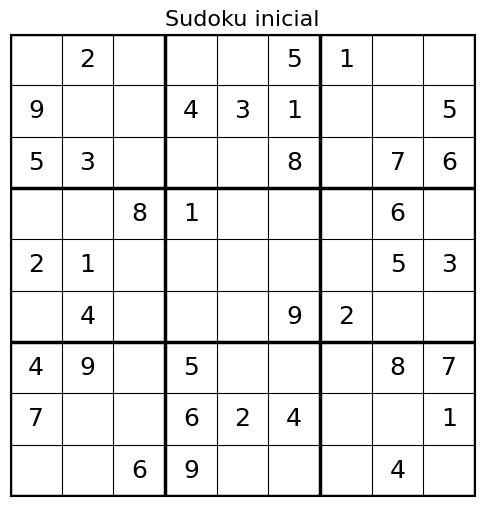

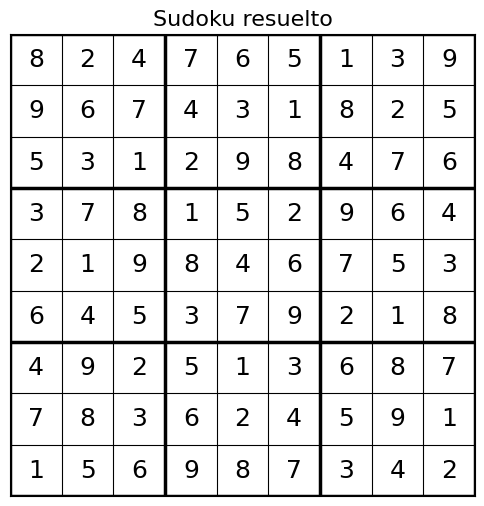

In [11]:
# Visualización
plot_sudoku_board(sudoku_matrix, "Sudoku inicial")
plot_sudoku_board(sudoku_solution, "Sudoku resuelto")

## 7. Guardar solución

In [ ]:
# Guardar solución
np.save(SUDOKU_SOLUTION_PATH, sudoku_solution)

print(f"Solución guardada en: {SUDOKU_SOLUTION_PATH}")

Solución guardada en: ..\notebooks\outputs\sudoku_solution.npy


In [13]:
# Guardar como CSV
SUDOKU_SOLUTION_CSV_PATH = OUTPUTS_DIR / "sudoku_solution.csv"

np.savetxt(
    SUDOKU_SOLUTION_CSV_PATH,
    sudoku_solution,
    fmt="%d",
    delimiter=","
)

print(f"Solución CSV guardada en: {SUDOKU_SOLUTION_CSV_PATH}")

Solución CSV guardada en: ..\notebooks\outputs\sudoku_solution.csv
